## Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [11]:
df = pd.read_csv('fish[1].csv',encoding='latin-1')

In [12]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


## Explore the Dataset

In [13]:
df.shape

(159, 7)

In [55]:
df.info

<bound method DataFrame.info of     Species  Weight  Length1  Length2  Length3   Height   Width
0     Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1     Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2     Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3     Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4     Bream   430.0     26.5     29.0     34.0  12.4440  5.1340
..      ...     ...      ...      ...      ...      ...     ...
154   Smelt    12.2     11.5     12.2     13.4   2.0904  1.3936
155   Smelt    13.4     11.7     12.4     13.5   2.4300  1.2690
156   Smelt    12.2     12.1     13.0     13.8   2.2770  1.2558
157   Smelt    19.7     13.2     14.3     15.2   2.8728  2.0672
158   Smelt    19.9     13.8     15.0     16.2   2.9322  1.8792

[159 rows x 7 columns]>

In [34]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [39]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

## Data Visualization

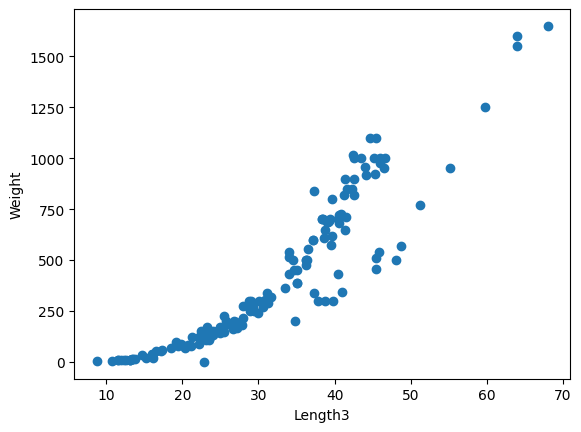

In [33]:
plt.scatter(df["Length3"], df["Weight"])
plt.xlabel("Length3")
plt.ylabel("Weight")

plt.show()

## 6. Feature Selection

In [17]:
x = df[['Length3','Height','Width']]
y = df['Weight']

In [19]:
x

,Length3,Height,Width
0,30.0,11.5200,4.0200
1,31.2,12.4800,4.3056
2,31.1,12.3778,4.6961
3,33.5,12.7300,4.4555
4,34.0,12.4440,5.1340
...,...,...,...
154,13.4,2.0904,1.3936
155,13.5,2.4300,1.2690
156,13.8,2.2770,1.2558
157,15.2,2.8728,2.0672


## Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [27]:
x_train.shape

(127, 3)

##  Build Linear Regression Model

In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

weight = B0 + B1(length3) + B2(height) + B3(width)


In [29]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
lr.intercept_

np.float64(-512.1743878158368)

In [45]:
for feature, coefficient in zip(x.columns, lr.coef_):
    print(feature, ":", coefficient)

Length3 : 21.265317421490288
Height : 1.4785762262855446
Width : 54.955766965969566


In [46]:
y_pred = lr.predict(x_test)
y_pred

array([ 522.27398245,  463.89144088, -165.10162164,  532.52855076,
        528.60010715,  703.7078925 ,  354.01098928, 1200.64849117,
        784.63043314,  787.91517402,  914.68806152,  688.41946643,
        802.60222169,  176.32776048,  209.3536224 ,  288.14878824,
        516.63335812,  680.23156653,  710.98082867,  540.42414955,
        174.7871571 ,  -36.90461478,  304.64761735,  181.89532038,
        714.42485038,  611.35485596,  158.27575456,  215.81145007,
        207.39541951,  425.55628206,  932.11604297,  755.19044681])

## Evaluate the Model

In [47]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [49]:
r2 = r2_score(y_test,y_pred)
print("r2 score:",r2)

r2 score: 0.8235499783339257


In [52]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

MAE: 110.84251544517639
MSE: 20202.118299887392


In [54]:
length3 = float(input("Enter Length3: "))
height = float(input("Enter Height: "))
width = float(input("Enter Width: "))

new_fish = pd.DataFrame({
    "Length3": [length3],
    "Height": [height],
    "Width": [width]
})

prediction = lr.predict(new_fish)

print("Predicted Weight:", prediction[0])

Enter Length3:  34.6
Enter Height:  12.88
Enter Width:  5.556


Predicted Weight: 547.983898025212
